# Milestone 1 — Parkinson's Disease Target Ranking

**Context.md §36.** A transparent, non-ML target ranking built only from Open Targets evidence.

> Scores here are *prioritization hypotheses*, not validated findings. A high score does not
> mean a target will yield an effective drug. See `docs/limitations.md`.

The logic lives in the package (Context.md §34 — notebooks are for exploration and
visualization, not for holding the pipeline). This notebook is a thin layer over it, so
anything you learn here is reproducible from the command line:

```bash
uv run python scripts/run_milestone1.py
```

In [1]:
import polars as pl

from target_prioritization.milestone1 import (
    KNOWN_PARKINSONS_GENES,
    ablation_movement,
    run_milestone_1,
)
from target_prioritization.models.baseline import SCORE_COLUMN

pl.Config.set_tbl_rows(25)
result = run_milestone_1(write_outputs=False)
result.disease.name, result.disease.efo_id, result.ranked.height

2026-07-30T04:41:36.346210Z [info     ] milestone_1_start              disease=parkinsons_disease disease_id=MONDO_0005180
2026-07-30T04:41:36.594714Z [info     ] candidates_loaded              candidates=8727 disease=parkinsons_disease disease_id=MONDO_0005180 evidence_rows=10725
2026-07-30T04:41:36.596347Z [info     ] leakage_guard_live             potential_columns=46 required_rules=['ot_clinical_precedence_datasource', 'prioritisation_max_clinical_stage']
2026-07-30T04:41:36.597557Z [info     ] denylisted_datasources_dropped datasources=['clinical_precedence'] reason='these encode the training label (Context.md §16)' rows_dropped=287
2026-07-30T04:41:36.597738Z [info     ] records_dropped                dropped=37 dropped_pct=0.424 reason='target had no evidence other than the denylisted label datasource, so it has no features to score' stage=candidates_lost_to_denylist total=8727
2026-07-30T04:41:36.599668Z [info     ] dimension_built                datasources_absent=['orphanet']

("Parkinson's disease", 'MONDO_0005180', 8690)

## 1. What the candidate set looks like

Candidate generation is deliberately simple (Context.md §13): every target Open Targets
associates with the disease. The interesting property is how *thin* the evidence is.

In [2]:
evidence_profile = (
    result.ranked.group_by("n_evidence_types")
    .len()
    .sort("n_evidence_types")
    .rename({"len": "n_targets"})
)
evidence_profile

n_evidence_types,n_targets
u32,u32
1,7164
2,1330
3,180
4,9
5,5
6,1
7,1


In [3]:
# The single most important fact about this dataset.
lit_only = result.ranked.filter(
    (pl.col("n_evidence_types") == 1) & pl.col("dim__literature").is_not_null()
)
print(
    f"{lit_only.height:,} of {result.ranked.height:,} candidates ({100 * lit_only.height / result.ranked.height:.0f}%) have literature evidence and nothing else."
)

6,196 of 8,690 candidates (71%) have literature evidence and nothing else.


That is why `literature` carries a low weight and why `evidence_diversity` is scored at all.
A score dominated by publication volume would rank genes by fame (Context.md §32.2).

## 2. The ranking

Contributions sum exactly to the score, so the table below is fully decomposable —
no SHAP required.

In [4]:
top20 = result.ranked.head(20).select(
    [
        "rank",
        "gene_symbol",
        SCORE_COLUMN,
        "dim__genetics",
        "n_evidence_types",
        "dim__functional",
        "dim__literature",
        "dim__druggability",
        "evidence_completeness",
    ]
)
top20

rank,gene_symbol,prioritization_score,dim__genetics,n_evidence_types,dim__functional,dim__literature,dim__druggability,evidence_completeness
u32,str,f64,f64,u32,f64,f64,f64,f64
1,"""LRRK2""",0.844495,0.865432,7,0.555804,0.988563,0.666667,1.0
2,"""PLA2G6""",0.832876,0.934097,4,0.358135,0.92567,0.666667,1.0
3,"""GBA1""",0.823161,0.937192,6,null,0.988563,1.0,0.8
4,"""MAPT""",0.817278,0.832464,4,0.464028,0.98681,0.666667,1.0
5,"""PARK7""",0.785541,0.929126,5,null,0.981494,0.666667,0.8
6,"""SNCA""",0.762803,0.856372,5,0.035592,0.988323,0.666667,1.0
7,"""ITPKB""",0.747114,0.803941,4,0.507545,0.773818,0.333333,1.0
8,"""PSAP""",0.739417,0.547467,4,0.865978,0.825779,0.666667,1.0
9,"""NR4A2""",0.732215,0.679881,4,0.347292,0.943347,0.666667,1.0


## 3. Does it recover known biology?

The one question this milestone exists to answer. These genes are **not labels** —
nothing in the scoring knows about them.

In [5]:
known = pl.DataFrame(
    {
        "gene_symbol": list(KNOWN_PARKINSONS_GENES.values()),
        "rank": [result.known_gene_ranks[s] for s in KNOWN_PARKINSONS_GENES.values()],
    }
).sort("rank")
print(known)
print(f"\nAcceptance check passed: {result.acceptance_passed}")

shape: (5, 2)
┌─────────────┬──────┐
│ gene_symbol ┆ rank │
│ ---         ┆ ---  │
│ str         ┆ i64  │
╞═════════════╪══════╡
│ LRRK2       ┆ 1    │
│ GBA1        ┆ 3    │
│ SNCA        ┆ 6    │
│ PINK1       ┆ 15   │
│ PRKN        ┆ 19   │
└─────────────┴──────┘

Acceptance check passed: True


## 4. Why did LRRK2 rank first?

The contributions decompose the score exactly.

In [6]:
explanation = result.explanations[0]
print(f"{explanation.gene_symbol}  score={explanation.score:.4f}")
print(f"evidence completeness: {explanation.evidence_completeness:.0%}")
print(f"missing dimensions: {explanation.missing_dimensions or 'none'}")
print()
for dimension, contribution in sorted(explanation.contributions.items(), key=lambda kv: -kv[1]):
    value = explanation.dimension_values[dimension]
    shown = f"{value:.3f}" if value is not None else "missing"
    print(f"  {dimension:20s} raw={shown:>8s}  contributes {contribution:.4f}")
print(f"\n  {'total':20s} {sum(explanation.contributions.values()):.4f}")

LRRK2  score=0.8445
evidence completeness: 100%
missing dimensions: none

  genetics             raw=   0.865  contributes 0.3462
  evidence_diversity   raw=   1.000  contributes 0.2000
  literature           raw=   0.989  contributes 0.1483
  functional           raw=   0.556  contributes 0.0834
  druggability         raw=   0.667  contributes 0.0667

  total                0.8445


## 5. How much of this is publication bias?

Context.md §32.2 requires measuring the ranking with and without literature evidence.
This is the most important cell in the notebook.

In [7]:
movement = ablation_movement(result, top_n=20).sort("rank_change")
movement.head(8)

target_id,gene_symbol,rank,rank_no_literature,rank_change
str,str,i64,i64,i64
"""ENSG00000158828""","""PINK1""",15,24,-9
"""ENSG00000185345""","""PRKN""",19,28,-9
"""ENSG00000069329""","""VPS35""",20,29,-9
"""ENSG00000109743""","""BST1""",13,20,-7
"""ENSG00000127419""","""TMEM175""",14,21,-7
"""ENSG00000130203""","""APOE""",11,16,-5
"""ENSG00000164733""","""CTSB""",12,17,-5
"""ENSG00000054983""","""GALC""",18,22,-4


In [8]:
survivors = result.known_genes_in_top_20_without_literature
print(
    f"Known genes in top 20 WITH literature:    {len(result.known_genes_in_top_20)}/5 — {result.known_genes_in_top_20}"
)
print(f"Known genes in top 20 WITHOUT literature: {len(survivors)}/5 — {survivors}")

Known genes in top 20 WITH literature:    5/5 — ['GBA1', 'LRRK2', 'PINK1', 'PRKN', 'SNCA']
Known genes in top 20 WITHOUT literature: 3/5 — ['GBA1', 'LRRK2', 'SNCA']


**Read this carefully.** PINK1 and PRKN fall out of the top 20 once publication
evidence is removed, so the headline result is partly literature-dependent.

That does not make literature worthless — PINK1 and PRKN genuinely matter. It means
this method cannot separate *well-published because important* from *merely often
mentioned*. Doing so needs labels and a held-out evaluation: Milestone 2.

## 6. Evidence breakdown figure

Stacked bars because contributions sum to the score — the stack total *is* the bar length.

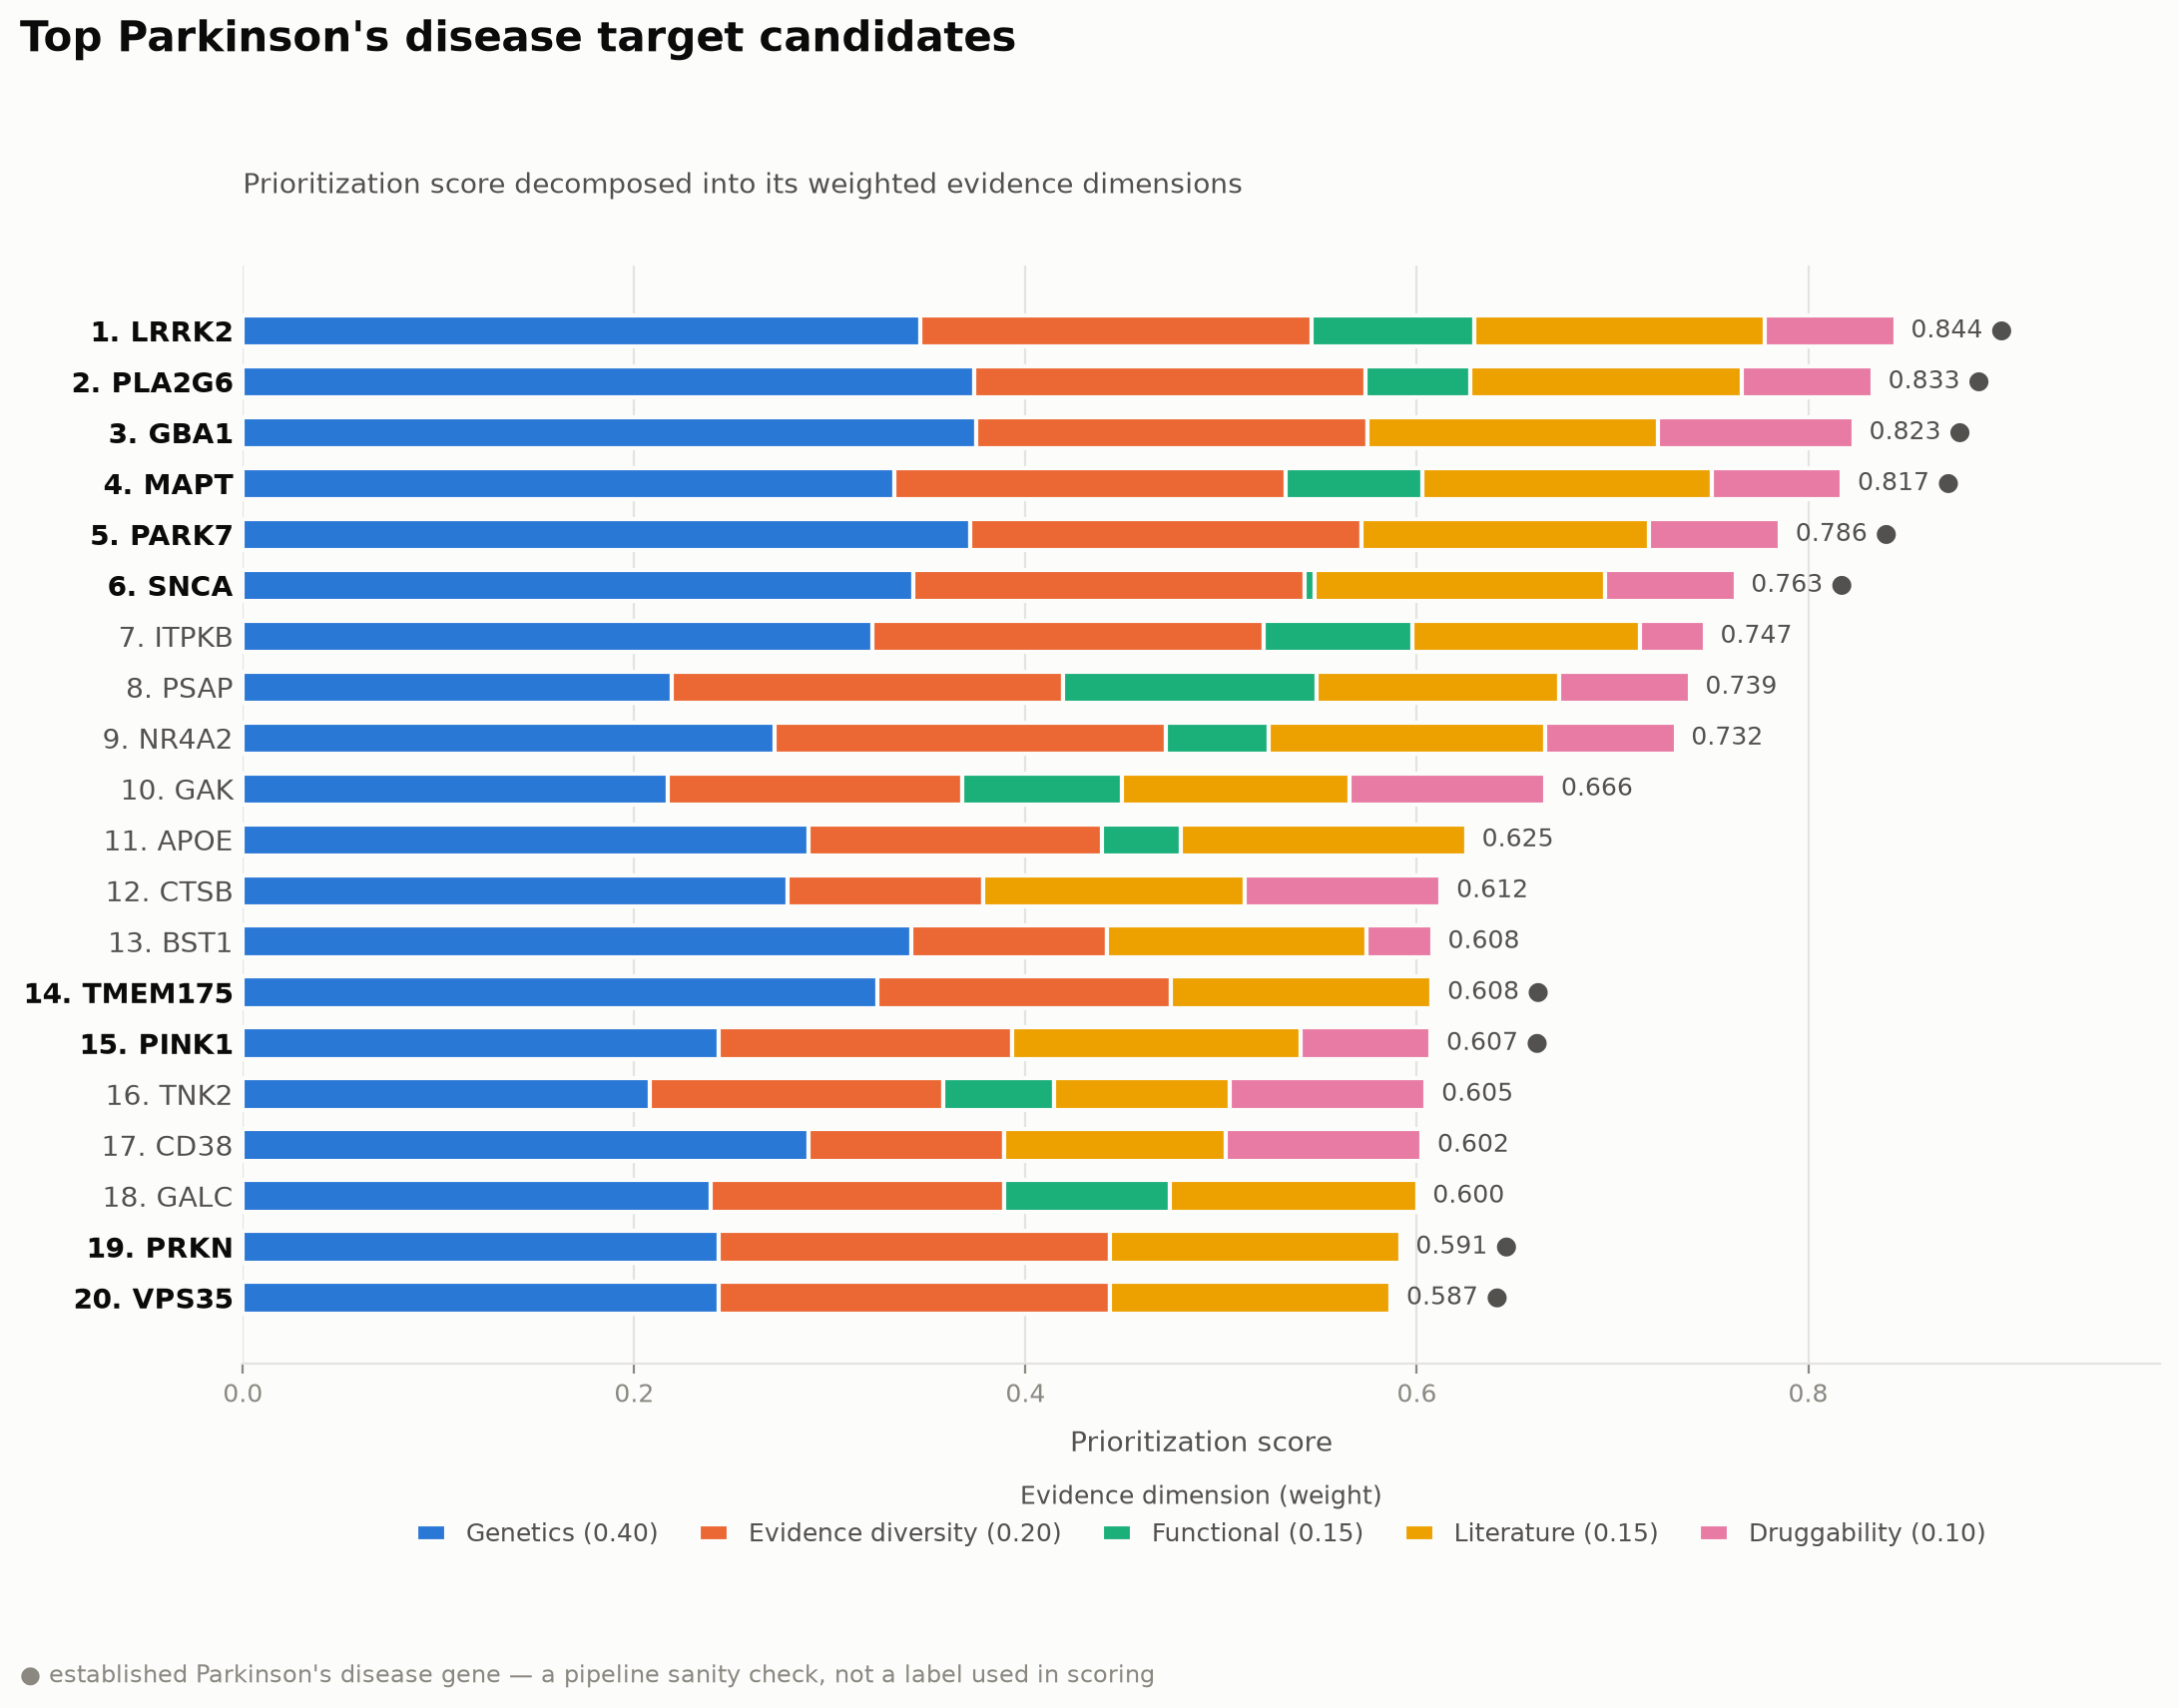

In [9]:
from IPython.display import Image

from target_prioritization.milestone1 import FIGURE_NAME
from target_prioritization.utils.paths import FIGURES_DIR

Image(filename=str(FIGURES_DIR / FIGURE_NAME))

## 7. Limitations

See `reports/parkinsons_baseline_report.md` section 6 for the full list. The three that
most constrain how this output should be read:

1. **The weights are arbitrary** — hand-set, tuned against no objective.
2. **This cannot discover anything new** — candidates are targets Open Targets *already*
   associates with Parkinson's, so the method re-ranks known associations (§13).
3. **No pathway, expression or network evidence** — three of the six §17.1 dimensions are
   absent, so a target whose case rests on those is under-scored here.